# Chapter 11: Hyperbolic Geometry

Source orientation: Pressley, printed pp. 270-304; PDF pp. 271-306; sections 11.1-11.5. The source PDF was read for chapter structure and terminology only. The explanations, code, checks, and diagrams here are original and do not reproduce textbook prose, exercises, screenshots, crops, or page layouts.

## Chapter Goal

Build hyperbolic geometry as a metric geometry that can be computed in several equivalent models. The upper half-plane makes the metric and vertical/circular geodesics explicit. The Poincare disk makes angle preservation and parallel behavior easy to inspect. Mobius maps supply isometries. The Beltrami-Klein disk trades conformality for straight geodesics and makes the cross-ratio distance formula visible.

## Route Through The Notebook

1. Translate the chapter's geometric objects into arrays, complex maps, and invariant checks.
2. Compare upper-half-plane geodesics with their Poincare disk images.
3. Act on points and geodesics with Mobius isometries and verify distance preservation.
4. Inspect horocycles, equidistant curves, limiting parallels, and the angle of parallelism.
5. Measure triangle angle defect and verify the hyperbolic cosine rule.
6. Move to the Beltrami-Klein model and check the cross-ratio distance formula.

The visuals are not decoration: each saved artifact has a nearby inspection target and at least one numeric or symbolic sanity check.

## How To Read The Visuals

Each model is useful for a different inspection task. In the upper half-plane, height controls scale, so the metric-density background explains why boundary-approaching motion is expensive. In the Poincare disk, Euclidean angles can be trusted, so tangent directions are enough for triangle angles and the angle of parallelism. Mobius panels should be read as invariant trackers: the visible picture moves, but the distance table and residuals stay fixed. Horocycles and equidistant rays are included because they are common traps: they are simple Euclidean curves, but the right-angle boundary test separates them from geodesics. The Klein panel should be read in the opposite way from the disk panel: straight chords make incidence and cross-ratio easy, while Euclidean angles should no longer be interpreted as hyperbolic angles.


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from matplotlib.patches import Arc
from IPython.display import IFrame, display

START = Path.cwd().resolve()
candidates = [START, *START.parents]
workspace_child = START / "Elementary-Differential-Geometry-Andrew-Pressley"
if workspace_child.exists():
    candidates.append(workspace_child)

for candidate in candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the Pressley book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact

UNIT = "chapter-11"
UNIT_ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT
FIG_DIR = UNIT_ARTIFACT_ROOT / "figures"
INTERACTIVE_DIR = UNIT_ARTIFACT_ROOT / "interactive"
CHECK_DIR = UNIT_ARTIFACT_ROOT / "checks"
TABLE_DIR = UNIT_ARTIFACT_ROOT / "tables"
for directory in (FIG_DIR, INTERACTIVE_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

artifact_paths: list[Path] = []
numeric_checks: dict[str, float | int | bool | str] = {}
symbolic_checks: dict[str, bool | str] = {}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})


def book_rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def notebook_rel(path: Path) -> str:
    return "../" + book_rel(Path(path))


def to_builtin(value):
    if isinstance(value, Path):
        return book_rel(value)
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, complex):
        return {"real": float(value.real), "imag": float(value.imag)}
    if isinstance(value, dict):
        return {str(k): to_builtin(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [to_builtin(v) for v in value]
    return value


def remember(path: Path) -> Path:
    path = Path(path)
    if path not in artifact_paths:
        artifact_paths.append(path)
    return path


def write_json(path: Path, data) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(to_builtin(data), indent=2, sort_keys=True), encoding="utf-8")
    return remember(path)


def save_figure(fig, filename: str) -> Path:
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return remember(path)


print(f"Book root discovered: {BOOK_ROOT.name}")
print(f"Chapter artifacts: {book_rel(UNIT_ARTIFACT_ROOT)}")


Book root discovered: Elementary-Differential-Geometry-Andrew-Pressley
Chapter artifacts: artifacts/chapter-11


## Computational Translation Guide

| Chapter idea | Computational representation | Check used here |
| --- | --- | --- |
| Upper half-plane metric $ds^2=(dv^2+dw^2)/w^2$ | Complex points $z=v+iw$ with $w>0$ and distance $2\operatorname{arctanh}\frac{|b-a|}{|b-\bar a|}$ | Cayley transfer preserves distance in the disk |
| Hyperbolic lines in $H$ | Vertical half-lines or Euclidean semicircles orthogonal to the real boundary | Sampled arcs stay in $w>0$ and meet the boundary orthogonally |
| Poincare disk | Cayley map $P(z)=(z-i)/(z+i)$ and disk distance $2\operatorname{arctanh}\frac{|b-a|}{|1-\bar a b|}$ | Half-plane and disk distance formulas agree |
| Isometries | Real Mobius maps on $H$ and disk automorphisms | Pairwise hyperbolic distances are unchanged |
| Horocycles and equidistant curves | Euclidean tangent circles/horizontal lines and rays at fixed distance from a line | Distance-to-line residual is near zero |
| Parallel behavior | Disk geodesics sharing an ideal endpoint with a given line | Numeric angle of parallelism satisfies $\sin \Pi=\operatorname{sech} d$ |
| Triangle area | Angle defect $\pi-(\alpha+\beta+\gamma)$ in the conformal disk | Defect is positive and the hyperbolic cosine rule closes |
| Beltrami-Klein model | Radial map $K(z)=2z/(1+|z|^2)$ sends disk geodesics to chords | Cross-ratio distance matches the Poincare distance |


In [2]:
source_span = {
    "book": "Andrew Pressley, Elementary Differential Geometry, Second Edition",
    "chapter": "Chapter 11: Hyperbolic geometry",
    "printed_pages": "270-304",
    "pdf_pages": "271-306",
    "sections": ["11.1", "11.2", "11.3", "11.4", "11.5"],
    "source_pdf": "Elementary Differential Geometry (Andrew Pressley).pdf",
    "use": "orientation only; no copied prose, exercises, screenshots, page crops, or figures",
}

storyboard = {
    "chapter goal": "Teach hyperbolic geometry through computable model changes, geodesics, isometries, parallels, angle defect, and cross-ratio distance.",
    "source span read": source_span,
    "concept inventory": [
        "Upper half-plane metric is conformal to the Euclidean plane but changes length by height.",
        "Hyperbolic lines in H are vertical rays and semicircles orthogonal to the real boundary.",
        "The Cayley map moves H to the Poincare disk and transfers distances, angles, and geodesics.",
        "Real Mobius maps with positive determinant act as orientation-preserving isometries of H.",
        "Horocycles and equidistant curves are not hyperbolic lines, even when Euclidean coordinates make them look simple.",
        "Nonintersecting lines split into limiting parallel and ultra-parallel behavior.",
        "Hyperbolic triangle area is angle defect; similar triangles are rigid rather than scaleable.",
        "The Beltrami-Klein model straightens geodesics but loses conformality; distance becomes a cross-ratio.",
    ],
    "library routing table": [
        {
            "concept": "2D model comparison and geodesic arcs",
            "representation": "static annotated diagrams",
            "library": "Matplotlib + NumPy",
            "why": "The models are planar and the teaching target is incidence, orthogonality, and labeled arcs.",
            "fallback": "plain SVG would work but would make numeric checks less direct",
        },
        {
            "concept": "Mobius isometry action",
            "representation": "slider-based disk automorphism artifact",
            "library": "Plotly",
            "why": "The parameter changes continuously, and an HTML artifact lets learners inspect the orbit without rerunning code.",
            "fallback": "a static before/after Matplotlib panel is also saved",
        },
        {
            "concept": "cross-ratio and Mobius invariance",
            "representation": "exact symbolic identity plus numeric Klein distance check",
            "library": "SymPy + NumPy",
            "why": "The projective invariant is algebraic, while the distance comparison is numeric.",
            "fallback": "numeric random tests only, with weaker assurance",
        },
    ],
    "visual sequence": [
        {
            "concept": "upper-half-plane geodesics and disk transfer",
            "representation": "side-by-side H and disk plot",
            "library": "Matplotlib/NumPy",
            "artifact filename": "upper-half-plane-and-disk-geodesics.png",
            "learner inspection target": "semicircles and vertical rays in H become disk arcs orthogonal to the unit circle",
            "validation/invariant": "d_H(a,b) equals d_D(P(a),P(b))",
        },
        {
            "concept": "Mobius isometry action on geodesics",
            "representation": "before/after H plot plus Plotly disk flow",
            "library": "Matplotlib, Plotly, SymPy",
            "artifact filename": "mobius-isometry-action-on-geodesics.png; mobius-isometry-flow.html",
            "learner inspection target": "geodesics map to geodesics while pairwise distances stay fixed",
            "validation/invariant": "maximum pairwise distance residual under the Mobius map",
        },
        {
            "concept": "horocycles and equidistant curves",
            "representation": "upper-half-plane families",
            "library": "Matplotlib/NumPy",
            "artifact filename": "horocycles-and-equidistant-curves.png",
            "learner inspection target": "fixed-distance rays and boundary-tangent horocycles are Euclidean-simple but not geodesics",
            "validation/invariant": "asinh(|v|/w) is constant along each ray",
        },
        {
            "concept": "angle of parallelism",
            "representation": "Poincare disk limiting parallels through a point",
            "library": "Matplotlib/NumPy",
            "artifact filename": "parallel-angle-and-limiting-geodesics.png",
            "learner inspection target": "only two nonintersecting geodesics through the point share an ideal endpoint with the line",
            "validation/invariant": "sin(Pi)=sech(d)",
        },
        {
            "concept": "triangle angle defect",
            "representation": "conformal disk triangle with measured angles",
            "library": "Matplotlib/NumPy",
            "artifact filename": "triangle-angle-defect-area.png",
            "learner inspection target": "angle sum is below pi and the defect is the area",
            "validation/invariant": "hyperbolic cosine rule residual",
        },
        {
            "concept": "Beltrami-Klein cross-ratio distance",
            "representation": "Poincare arc compared with Klein chord",
            "library": "Matplotlib/NumPy/SymPy",
            "artifact filename": "beltrami-klein-cross-ratio-distance.png",
            "learner inspection target": "the same geodesic is curved in Poincare and straight in Klein",
            "validation/invariant": "0.5*abs(log cross-ratio) equals Poincare distance",
        },
    ],
    "artifact plan": {
        "figures": [
            "artifacts/chapter-11/figures/upper-half-plane-and-disk-geodesics.png",
            "artifacts/chapter-11/figures/mobius-isometry-action-on-geodesics.png",
            "artifacts/chapter-11/figures/horocycles-and-equidistant-curves.png",
            "artifacts/chapter-11/figures/parallel-angle-and-limiting-geodesics.png",
            "artifacts/chapter-11/figures/triangle-angle-defect-area.png",
            "artifacts/chapter-11/figures/beltrami-klein-cross-ratio-distance.png",
        ],
        "interactive": ["artifacts/chapter-11/interactive/mobius-isometry-flow.html"],
        "checks": [
            "artifacts/chapter-11/checks/source-span.json",
            "artifacts/chapter-11/checks/visual-storyboard.json",
            "artifacts/chapter-11/checks/final-sanity.json",
            "artifacts/chapter-11/checks/notebook-sanity.json",
        ],
        "tables": ["artifacts/chapter-11/tables/mobius-invariance-lab.csv"],
    },
    "computational checks": [
        "artifact existence and nonzero file size",
        "Cayley distance transfer H -> DP",
        "Mobius pairwise distance invariance",
        "equidistant ray residuals",
        "parallel-angle formula residual",
        "triangle angle defect positivity and hyperbolic cosine rule residual",
        "Beltrami-Klein cross-ratio distance residual",
        "symbolic cross-ratio invariance under a generic Mobius map",
    ],
    "proof-visualization strategy": "Use invariant trackers rather than copied proof diagrams: distance preservation under isometries, angle-defect area, limiting-parallel angle, and cross-ratio invariance expose the proof state numerically or symbolically.",
    "implementation notes": [
        "All outputs are written under the chapter-11 artifact subtree.",
        "Matplotlib is used for durable 2D geometric diagrams; Plotly is reserved for the parameterized Mobius flow; SymPy checks the projective invariant exactly.",
        "No shared utilities or indexes are edited.",
    ],
    "risks": [
        "Plotly HTML display depends on notebook frontend support, so a static Mobius panel is also saved.",
        "Angles in the Poincare disk are measured with sampled geodesic tangents; tolerances are explicit.",
    ],
    "acceptance criteria": [
        "The notebook executes with nbclient.",
        "Every planned artifact exists under artifacts/chapter-11 and is nonblank.",
        "All numeric residuals are below the stated tolerances.",
        "The final sanity JSON records the source span, artifacts, libraries, and checks.",
    ],
}

write_json(CHECK_DIR / "source-span.json", source_span)
write_json(CHECK_DIR / "visual-storyboard.json", storyboard)
storyboard["visual sequence"]


[{'concept': 'upper-half-plane geodesics and disk transfer',
  'representation': 'side-by-side H and disk plot',
  'library': 'Matplotlib/NumPy',
  'artifact filename': 'upper-half-plane-and-disk-geodesics.png',
  'learner inspection target': 'semicircles and vertical rays in H become disk arcs orthogonal to the unit circle',
  'validation/invariant': 'd_H(a,b) equals d_D(P(a),P(b))'},
 {'concept': 'Mobius isometry action on geodesics',
  'representation': 'before/after H plot plus Plotly disk flow',
  'library': 'Matplotlib, Plotly, SymPy',
  'artifact filename': 'mobius-isometry-action-on-geodesics.png; mobius-isometry-flow.html',
  'learner inspection target': 'geodesics map to geodesics while pairwise distances stay fixed',
  'validation/invariant': 'maximum pairwise distance residual under the Mobius map'},
 {'concept': 'horocycles and equidistant curves',
  'representation': 'upper-half-plane families',
  'library': 'Matplotlib/NumPy',
  'artifact filename': 'horocycles-and-equid

## Model And Geodesic Helpers

The chapter is naturally two-dimensional, so the core objects can be represented by complex numbers. The helper functions below are deliberately small: they keep the formulas visible while preventing the later visual cells from becoming opaque. The two most important maps are the Cayley map from the upper half-plane to the disk and the Beltrami-Klein radial map from the Poincare disk to the Klein disk.


In [3]:
EPS = 1e-12


def P(z):
    z = np.asarray(z, dtype=np.complex128)
    return (z - 1j) / (z + 1j)


def Pinv(z):
    z = np.asarray(z, dtype=np.complex128)
    return 1j * (1 + z) / (1 - z)


def scalar_complex(z) -> complex:
    return complex(np.asarray(z).item())


def hyp_dist_h(a: complex, b: complex) -> float:
    ratio = abs(b - a) / abs(b - np.conjugate(a))
    return float(2 * np.arctanh(np.clip(ratio, 0.0, 1.0 - 1e-15)))


def hyp_dist_disk(a: complex, b: complex) -> float:
    ratio = abs(b - a) / abs(1 - np.conjugate(a) * b)
    return float(2 * np.arctanh(np.clip(ratio, 0.0, 1.0 - 1e-15)))


def disk_translate(z, t: float):
    r = np.tanh(t / 2)
    z = np.asarray(z, dtype=np.complex128)
    return (z + r) / (r * z + 1)


def real_mobius(z, a: float, b: float, c: float, d: float):
    det = a * d - b * c
    if det <= 0:
        raise ValueError("positive determinant required to map H to H")
    z = np.asarray(z, dtype=np.complex128)
    return (a * z + b) / (c * z + d)


def uhp_geodesic_segment(a: complex, b: complex, n: int = 300) -> np.ndarray:
    a, b = complex(a), complex(b)
    if abs(a.real - b.real) < EPS:
        y = np.linspace(a.imag, b.imag, n)
        return a.real + 1j * y
    center = (abs(b) ** 2 - abs(a) ** 2) / (2 * (b.real - a.real))
    radius = abs(a - center)
    theta_a = np.angle(a - center)
    theta_b = np.angle(b - center)
    if theta_a < 0:
        theta_a += 2 * np.pi
    if theta_b < 0:
        theta_b += 2 * np.pi
    return center + radius * np.exp(1j * np.linspace(theta_a, theta_b, n))


def uhp_geodesic_full(a: complex, b: complex, n: int = 400, y_top: float = 3.0) -> np.ndarray:
    a, b = complex(a), complex(b)
    if abs(a.real - b.real) < EPS:
        return a.real + 1j * np.linspace(0.04, y_top, n)
    center = (abs(b) ** 2 - abs(a) ** 2) / (2 * (b.real - a.real))
    radius = abs(a - center)
    theta = np.linspace(0.03, np.pi - 0.03, n)
    return center + radius * np.exp(1j * theta)


def disk_geodesic_segment(a: complex, b: complex, n: int = 300) -> np.ndarray:
    return P(uhp_geodesic_segment(scalar_complex(Pinv(a)), scalar_complex(Pinv(b)), n=n))


def disk_circle_from_point_and_boundary(z: complex, endpoint: complex) -> tuple[complex, float]:
    z, endpoint = complex(z), complex(endpoint)
    A = np.array([[endpoint.real, endpoint.imag], [2 * z.real, 2 * z.imag]], dtype=float)
    rhs = np.array([1.0, abs(z) ** 2 + 1.0], dtype=float)
    center_xy = np.linalg.solve(A, rhs)
    center = center_xy[0] + 1j * center_xy[1]
    return center, math.sqrt(max(abs(center) ** 2 - 1.0, 0.0))


def disk_arc_from_circle(center: complex, radius: float, must_contain: complex | None = None, n: int = 400) -> np.ndarray:
    rho = abs(center)
    phi = np.angle(center)
    delta = math.acos(np.clip(1 / rho, -1, 1))
    endpoints = [np.exp(1j * (phi - delta)), np.exp(1j * (phi + delta))]
    angles = [np.angle(point - center) for point in endpoints]
    candidates = []
    for start, end in [(angles[0], angles[1]), (angles[1], angles[0])]:
        if end < start:
            end += 2 * np.pi
        pts = center + radius * np.exp(1j * np.linspace(start, end, n))
        inside_fraction = float(np.mean(np.abs(pts) <= 1 + 2e-3))
        contain_score = 0.0 if must_contain is None else float(np.min(np.abs(pts - must_contain)))
        candidates.append((inside_fraction, contain_score, pts))
    candidates.sort(key=lambda item: (-item[0], item[1]))
    return candidates[0][2]


def disk_geodesic_through_point_to_boundary(z: complex, endpoint: complex, n: int = 400) -> np.ndarray:
    center, radius = disk_circle_from_point_and_boundary(z, endpoint)
    return disk_arc_from_circle(center, radius, must_contain=z, n=n)


def poincare_to_klein(z):
    z = np.asarray(z, dtype=np.complex128)
    return 2 * z / (1 + np.abs(z) ** 2)


def klein_to_poincare(k):
    k = np.asarray(k, dtype=np.complex128)
    rho = np.abs(k)
    return k / (1 + np.sqrt(np.maximum(0, 1 - rho ** 2)))


def klein_chord_boundary(a: complex, b: complex):
    a, b = complex(a), complex(b)
    direction = (b - a) / abs(b - a)
    B = 2 * np.real(a * np.conjugate(direction))
    C = abs(a) ** 2 - 1
    roots = np.sort(np.roots([1, B, C]).real)
    return a + roots[0] * direction, a + roots[1] * direction, roots[0], roots[1], direction


def cross_ratio_real(ta: float, tb: float, tc: float, td: float) -> float:
    return float(((ta - tc) * (tb - td)) / ((ta - td) * (tb - tc)))


def angle_between(u: complex, v: complex) -> float:
    dot = (u.real * v.real) + (u.imag * v.imag)
    return float(np.arccos(np.clip(dot / (abs(u) * abs(v)), -1, 1)))


def tangent_from_segment(points: np.ndarray, at_start: bool = True) -> complex:
    return complex(points[1] - points[0]) if at_start else complex(points[-2] - points[-1])



def disk_geodesic_tangent(p: complex, q: complex) -> complex:
    p, q = complex(p), complex(q)
    # Diameter geodesics occur when p, q, and 0 are collinear.
    if abs(np.imag(p * np.conjugate(q))) < 1e-12:
        return q - p
    A = np.array([[2 * p.real, 2 * p.imag], [2 * q.real, 2 * q.imag]], dtype=float)
    rhs = np.array([abs(p) ** 2 + 1, abs(q) ** 2 + 1], dtype=float)
    center_xy = np.linalg.solve(A, rhs)
    center = center_xy[0] + 1j * center_xy[1]
    tangent = 1j * (p - center)
    chord_hint = q - p
    if tangent.real * chord_hint.real + tangent.imag * chord_hint.imag < 0:
        tangent = -tangent
    return tangent


def format_uhp(ax, xlim=(-3, 3), ylim=(0, 3), title=""):
    ax.axhline(0, color="black", lw=1.2)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("v")
    ax.set_ylabel("w")
    ax.set_title(title)
    ax.grid(True, color="#d8d8d8", lw=0.5)


def format_disk(ax, title=""):
    theta = np.linspace(0, 2 * np.pi, 500)
    ax.plot(np.cos(theta), np.sin(theta), color="black", lw=1.2)
    ax.set_xlim(-1.08, 1.08)
    ax.set_ylim(-1.08, 1.08)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_title(title)
    ax.grid(True, color="#e2e2e2", lw=0.5)


def plot_complex_curve(ax, pts, **kwargs):
    pts = np.asarray(pts, dtype=np.complex128)
    ax.plot(pts.real, pts.imag, **kwargs)


z_test = 0.3 + 1.7j
w_test = 0.25 + 0.2j
assert abs(scalar_complex(Pinv(P(z_test))) - z_test) < 1e-12
assert abs(scalar_complex(P(Pinv(w_test))) - w_test) < 1e-12
assert hyp_dist_h(1j, 2j) > 0


## 11.1 Upper Half-Plane And Disk Geodesics

In the upper half-plane, the metric is Euclidean length divided by height. Near the real boundary, the same Euclidean move costs more hyperbolic length. Geodesics are exactly the curves that hit the boundary at right angles: vertical half-lines and semicircles with centers on the real axis.

The Poincare disk is obtained by the Cayley map. Because the map is an isometry by definition of the disk model, the same geodesic segment should have the same hyperbolic length after transfer. Inspect the figure for two facts at once: geodesics remain boundary-orthogonal, and Euclidean shape changes under the model change while hyperbolic distance does not.


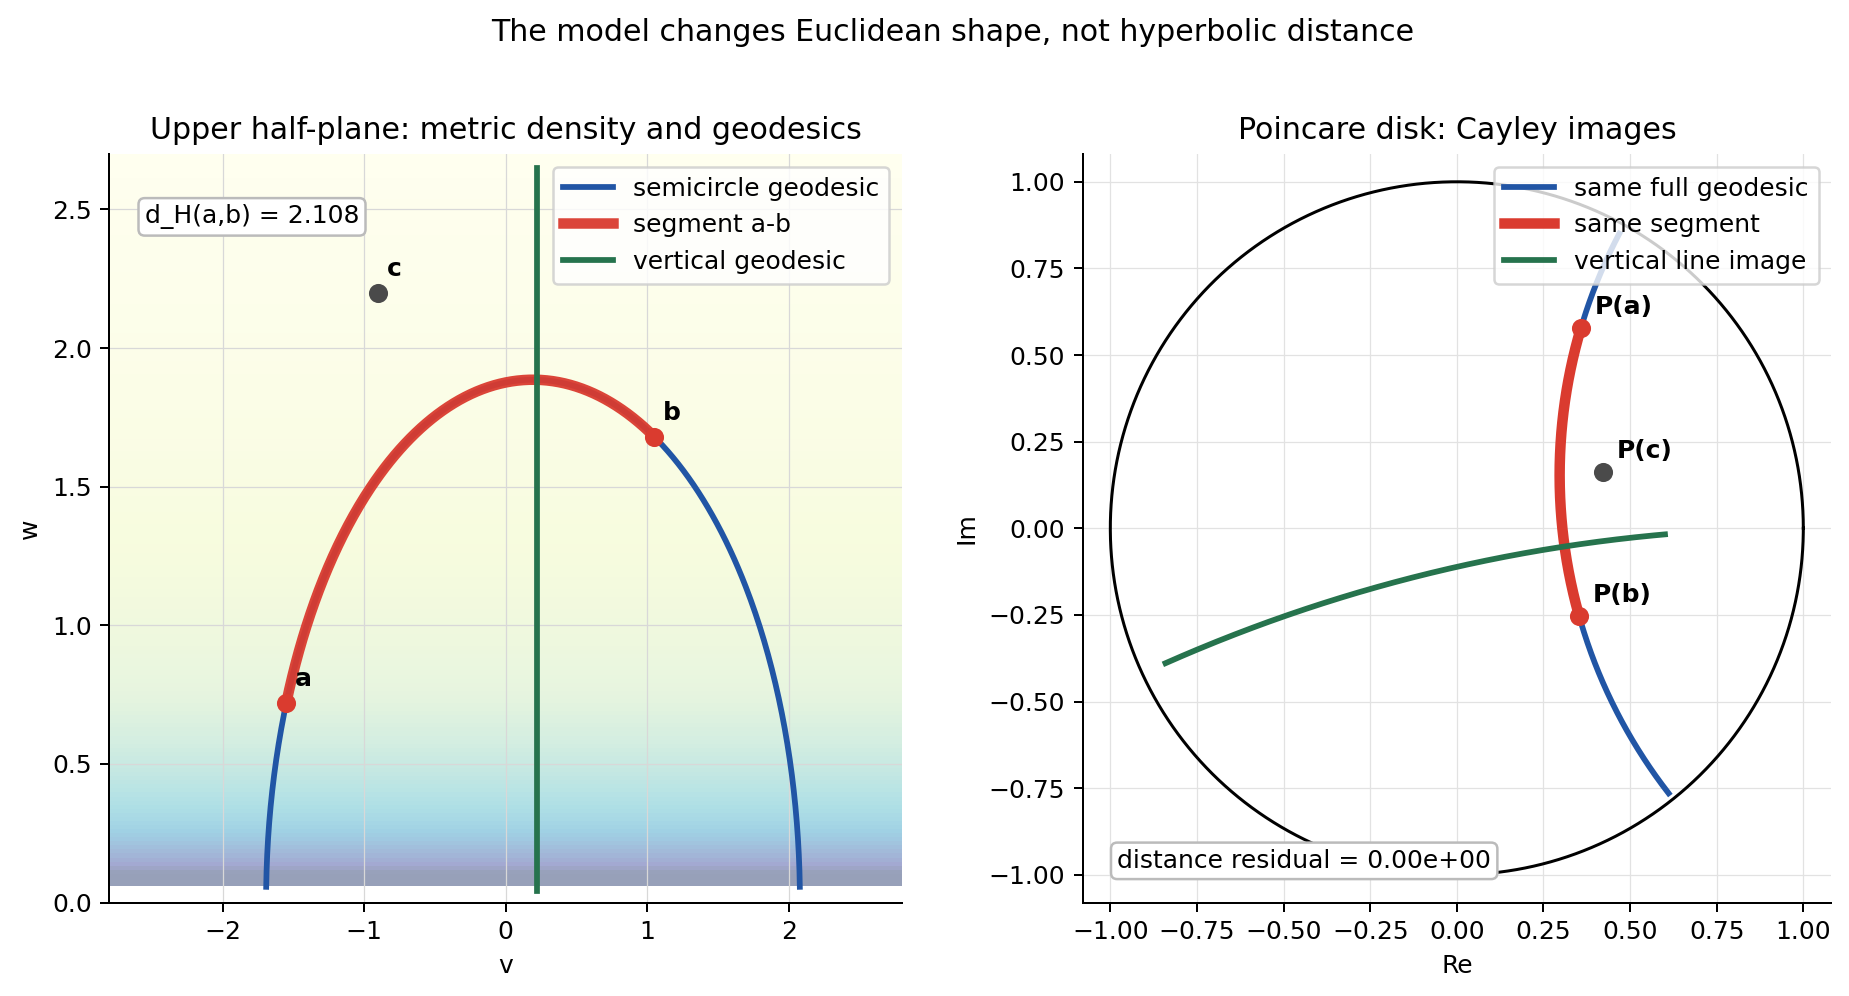

In [4]:
a_h = -1.55 + 0.72j
b_h = 1.05 + 1.68j
v1_h = 0.22 + 0.35j
v2_h = 0.22 + 2.35j
c_h = -0.9 + 2.2j

d_h = hyp_dist_h(a_h, b_h)
d_d = hyp_dist_disk(scalar_complex(P(a_h)), scalar_complex(P(b_h)))
numeric_checks["cayley_distance_residual"] = abs(d_h - d_d)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
ax = axes[0]
format_uhp(ax, xlim=(-2.8, 2.8), ylim=(0, 2.7), title="Upper half-plane: metric density and geodesics")
x = np.linspace(-2.8, 2.8, 220)
y = np.linspace(0.06, 2.7, 180)
X, Y = np.meshgrid(x, y)
metric_density = np.clip(1 / Y, 0, 10)
ax.imshow(np.log1p(metric_density), extent=[x.min(), x.max(), y.min(), y.max()], origin="lower", cmap="YlGnBu", alpha=0.42, aspect="auto")
plot_complex_curve(ax, uhp_geodesic_full(a_h, b_h, y_top=2.8), color="#2155a5", lw=2.3, label="semicircle geodesic")
plot_complex_curve(ax, uhp_geodesic_segment(a_h, b_h), color="#da3b2f", lw=4.2, alpha=0.95, label="segment a-b")
plot_complex_curve(ax, uhp_geodesic_full(v1_h, v2_h, y_top=2.65), color="#26734d", lw=2.3, label="vertical geodesic")
for point, label, color in [(a_h, "a", "#da3b2f"), (b_h, "b", "#da3b2f"), (c_h, "c", "#4a4a4a")]:
    ax.scatter(point.real, point.imag, s=44, color=color, zorder=5)
    ax.text(point.real + 0.06, point.imag + 0.06, label, weight="bold")
ax.text(-2.55, 2.45, f"d_H(a,b) = {d_h:.3f}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right")

ax = axes[1]
format_disk(ax, title="Poincare disk: Cayley images")
for pts, color, lw, label in [
    (P(uhp_geodesic_full(a_h, b_h, y_top=2.8)), "#2155a5", 2.3, "same full geodesic"),
    (P(uhp_geodesic_segment(a_h, b_h)), "#da3b2f", 4.2, "same segment"),
    (P(uhp_geodesic_full(v1_h, v2_h, y_top=4.0)), "#26734d", 2.3, "vertical line image"),
]:
    plot_complex_curve(ax, pts, color=color, lw=lw, label=label)
for point, label, color in [(scalar_complex(P(a_h)), "P(a)", "#da3b2f"), (scalar_complex(P(b_h)), "P(b)", "#da3b2f"), (scalar_complex(P(c_h)), "P(c)", "#4a4a4a")]:
    ax.scatter(point.real, point.imag, s=44, color=color, zorder=5)
    ax.text(point.real + 0.04, point.imag + 0.04, label, weight="bold")
ax.text(-0.98, -0.98, f"distance residual = {numeric_checks['cayley_distance_residual']:.2e}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right")
fig.suptitle("The model changes Euclidean shape, not hyperbolic distance", y=1.02)
path = save_figure(fig, "upper-half-plane-and-disk-geodesics.png")
display_artifact(path, width=980)


## 11.2-11.3 Mobius Isometries

The elementary isometries in the upper half-plane combine into real Mobius maps with positive determinant. The important computational test is direct: if a map is an isometry, every pairwise hyperbolic distance among a finite sample of points should be unchanged. The static panel shows one real Mobius map carrying a geodesic triangle to another geodesic triangle. The HTML artifact below adds a one-parameter disk flow so the action can be inspected continuously.

A separate symbolic check records the algebraic reason the Klein distance formula later works: cross-ratio is invariant under a generic Mobius transformation.


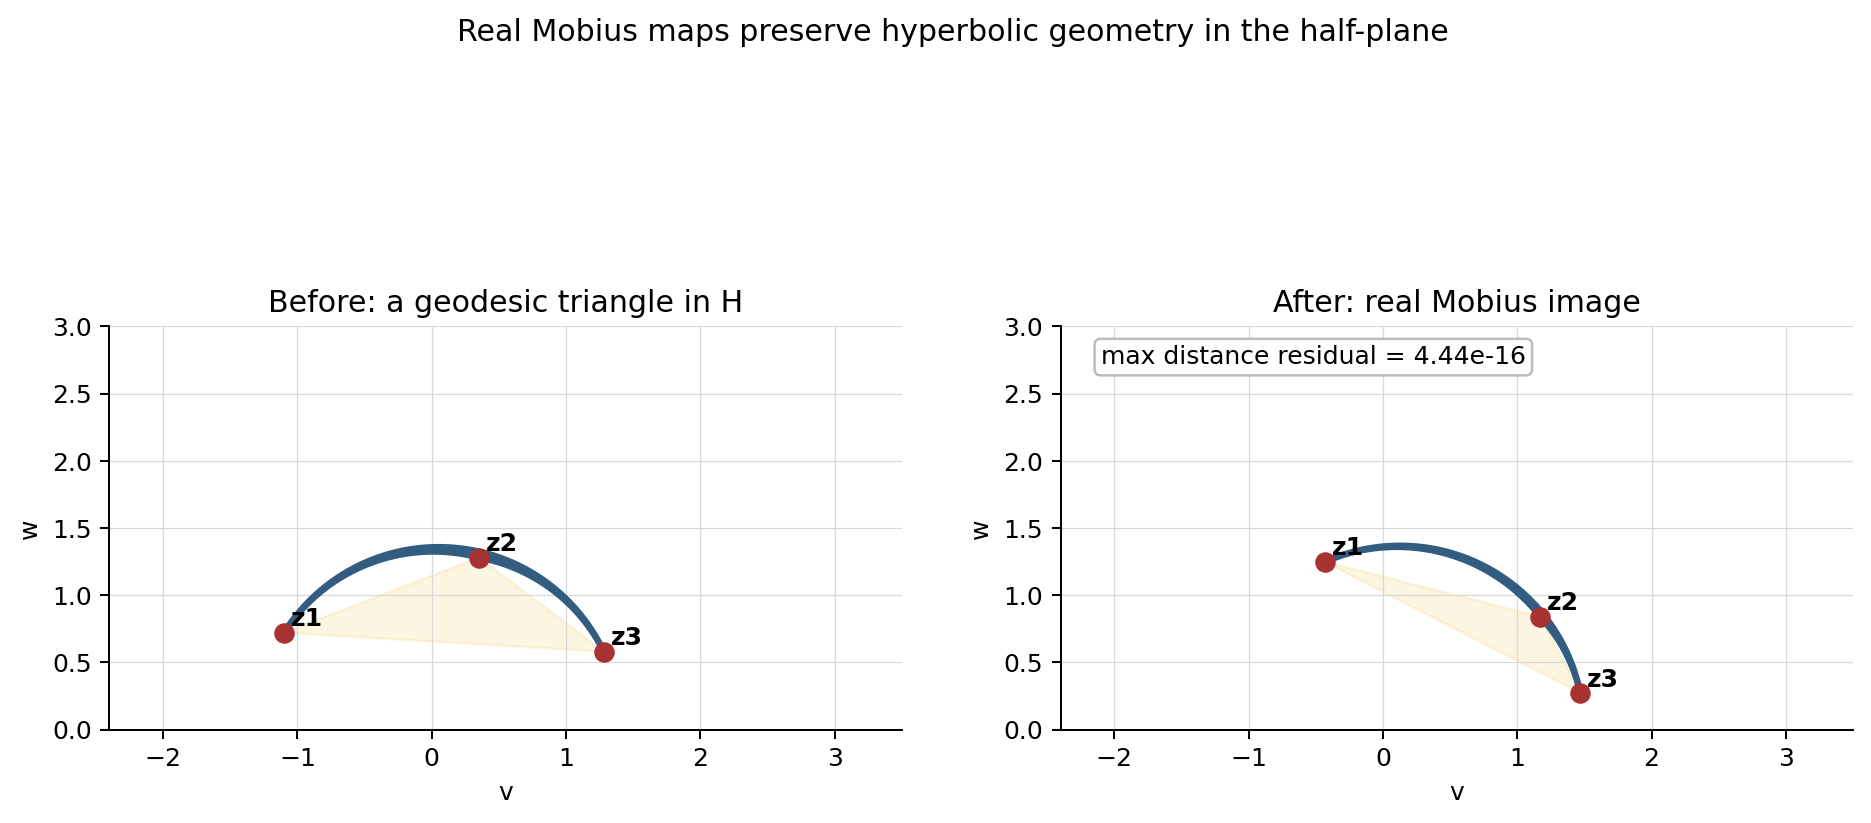

In [5]:
sample_h = np.array([-1.1 + 0.72j, 0.35 + 1.28j, 1.28 + 0.58j], dtype=np.complex128)
A_m, B_m, C_m, D_m = 1.25, 0.72, 0.34, 1.18
image_h = real_mobius(sample_h, A_m, B_m, C_m, D_m)

residuals = []
for i in range(len(sample_h)):
    for j in range(i + 1, len(sample_h)):
        before = hyp_dist_h(sample_h[i], sample_h[j])
        after = hyp_dist_h(complex(image_h[i]), complex(image_h[j]))
        residuals.append(abs(before - after))
numeric_checks["mobius_max_distance_residual"] = max(residuals)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax, points, title in [
    (axes[0], sample_h, "Before: a geodesic triangle in H"),
    (axes[1], image_h, "After: real Mobius image"),
]:
    format_uhp(ax, xlim=(-2.4, 3.5), ylim=(0, 3.0), title=title)
    for i, j in [(0, 1), (1, 2), (2, 0)]:
        plot_complex_curve(ax, uhp_geodesic_segment(points[i], points[j]), color="#335c81", lw=2.5)
    ax.fill(points.real, points.imag, color="#f0c85a", alpha=0.18)
    ax.scatter(points.real, points.imag, s=52, color="#a83232", zorder=5)
    for idx, point in enumerate(points):
        ax.text(point.real + 0.05, point.imag + 0.05, f"z{idx+1}", weight="bold")
axes[1].text(-2.1, 2.72, f"max distance residual = {numeric_checks['mobius_max_distance_residual']:.2e}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
fig.suptitle("Real Mobius maps preserve hyperbolic geometry in the half-plane", y=1.02)
path = save_figure(fig, "mobius-isometry-action-on-geodesics.png")
display_artifact(path, width=980)

base_points = np.array([-0.45 + 0.15j, -0.2 + 0.55j, 0.18 + 0.35j, 0.42 - 0.08j, -0.08 - 0.35j])
base_geodesic = disk_geodesic_segment(-0.55 + 0.15j, 0.5 + 0.42j, n=160)
t_values = np.linspace(-1.8, 1.8, 25)
boundary_theta = np.linspace(0, 2 * np.pi, 300)
initial_points = disk_translate(base_points, float(t_values[0]))
initial_geo = disk_translate(base_geodesic, float(t_values[0]))
fig_html = go.Figure(data=[
    go.Scatter(x=np.cos(boundary_theta), y=np.sin(boundary_theta), mode="lines", name="ideal boundary", line={"color": "black", "width": 2}),
    go.Scatter(x=initial_points.real, y=initial_points.imag, mode="markers", name="sample points", marker={"size": 9, "color": "#a83232"}),
    go.Scatter(x=initial_geo.real, y=initial_geo.imag, mode="lines", name="sample geodesic", line={"color": "#2155a5", "width": 4}),
])
fig_html.frames = [
    go.Frame(
        name=f"{t:.2f}",
        data=[
            go.Scatter(x=disk_translate(base_points, float(t)).real, y=disk_translate(base_points, float(t)).imag),
            go.Scatter(x=disk_translate(base_geodesic, float(t)).real, y=disk_translate(base_geodesic, float(t)).imag),
        ],
        traces=[1, 2],
    )
    for t in t_values
]
fig_html.update_layout(
    title="Disk Mobius isometry flow z -> (z + tanh(t/2))/(tanh(t/2) z + 1)",
    xaxis={"range": [-1.05, 1.05], "scaleanchor": "y", "title": "Re"},
    yaxis={"range": [-1.05, 1.05], "title": "Im"},
    width=760,
    height=700,
    margin={"l": 40, "r": 20, "t": 70, "b": 40},
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "t = "},
        "steps": [{"label": f"{t:.1f}", "method": "animate", "args": [[f"{t:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}]} for t in t_values],
    }],
)
html_path = INTERACTIVE_DIR / "mobius-isometry-flow.html"
fig_html.write_html(html_path, include_plotlyjs="cdn", full_html=True)
remember(html_path)
display(IFrame(src=notebook_rel(html_path), width="100%", height=560))

x1, x2, x3, x4, aa, bb, cc, dd = sp.symbols("x1 x2 x3 x4 aa bb cc dd")
M = lambda z: (aa * z + bb) / (cc * z + dd)
cr = lambda p, q, r, s: ((p - r) * (q - s)) / ((p - s) * (q - r))
symbolic_residual = sp.factor(sp.together(cr(M(x1), M(x2), M(x3), M(x4)) - cr(x1, x2, x3, x4)))
assert symbolic_residual == 0
symbolic_checks["cross_ratio_mobius_invariance"] = True
numeric_checks["sympy_cross_ratio_invariance"] = True


## Horocycles And Equidistant Curves

Hyperbolic geometry separates ideas that Euclidean geometry often merges. A horocycle is a curve with one ideal point as its center: in the upper half-plane, horizontal lines are horocycles based at infinity, and Euclidean circles tangent to the boundary are horocycles based at their tangency point. These are not geodesics.

Equidistant curves from a geodesic are also not geodesics. For the imaginary axis in $H$, the points at distance $R$ satisfy $|v|/w=\sinh R$, so they form Euclidean rays through the origin. The plot makes that contrast visible: geodesics hit the boundary orthogonally, while the fixed-distance rays do not.


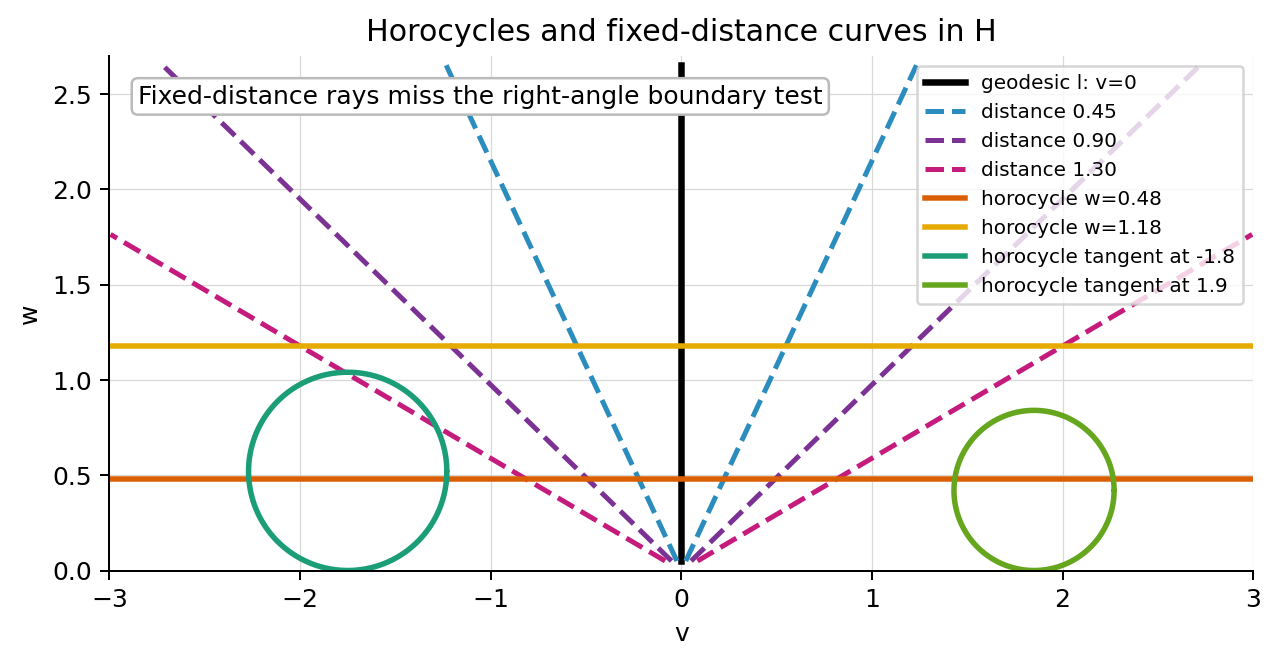

In [6]:
fig, ax = plt.subplots(figsize=(8.2, 6.2))
format_uhp(ax, xlim=(-3.0, 3.0), ylim=(0, 2.7), title="Horocycles and fixed-distance curves in H")
y_vals = np.linspace(0.05, 2.65, 300)
ax.plot(np.zeros_like(y_vals), y_vals, color="black", lw=2.6, label="geodesic l: v=0")

ray_residuals = []
for R, color in [(0.45, "#2b8cbe"), (0.90, "#7b3294"), (1.30, "#c51b7d")]:
    slope = math.sinh(R)
    for sign in [-1, 1]:
        x_ray = sign * slope * y_vals
        mask = np.abs(x_ray) <= 3.0
        ax.plot(x_ray[mask], y_vals[mask], color=color, lw=2.0, ls="--", label=f"distance {R:.2f}" if sign == 1 else None)
        samples_y = np.linspace(0.25, 2.2, 8)
        samples_x = sign * slope * samples_y
        measured = np.arcsinh(np.abs(samples_x) / samples_y)
        ray_residuals.extend(np.abs(measured - R))

for y0, color in [(0.48, "#d95f02"), (1.18, "#e6ab02")]:
    ax.plot(np.linspace(-3, 3, 300), np.full(300, y0), color=color, lw=2.2, label=f"horocycle w={y0}")
for center_x, radius, color in [(-1.75, 0.52, "#1b9e77"), (1.85, 0.42, "#66a61e")]:
    theta = np.linspace(0.02, 2 * np.pi - 0.02, 400)
    pts = center_x + 1j * radius + radius * np.exp(1j * theta)
    pts = pts[pts.imag >= 0]
    plot_complex_curve(ax, pts, color=color, lw=2.2, label=f"horocycle tangent at {center_x:.1f}")

ax.text(-2.85, 2.45, "Fixed-distance rays miss the right-angle boundary test", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right", fontsize=8)
numeric_checks["equidistant_ray_max_residual"] = float(np.max(ray_residuals))
path = save_figure(fig, "horocycles-and-equidistant-curves.png")
display_artifact(path, width=760)


## 11.4 Limiting Parallels And The Angle Of Parallelism

In the disk model, let $l$ be the real diameter and let $a=ir$ sit above it. The perpendicular from $a$ to $l$ is the imaginary diameter. Among the infinitely many geodesics through $a$ that do not meet $l$ inside the disk, exactly two are limiting parallels to $l$: they share one ideal endpoint with $l$.

The angle between the perpendicular and either limiting parallel is the angle of parallelism $\Pi$. The chapter formula is $\sin\Pi=\operatorname{sech} d$, where $d$ is the distance from $a$ to $l$. The diagram measures this angle directly from the tangent circle and checks the formula numerically.


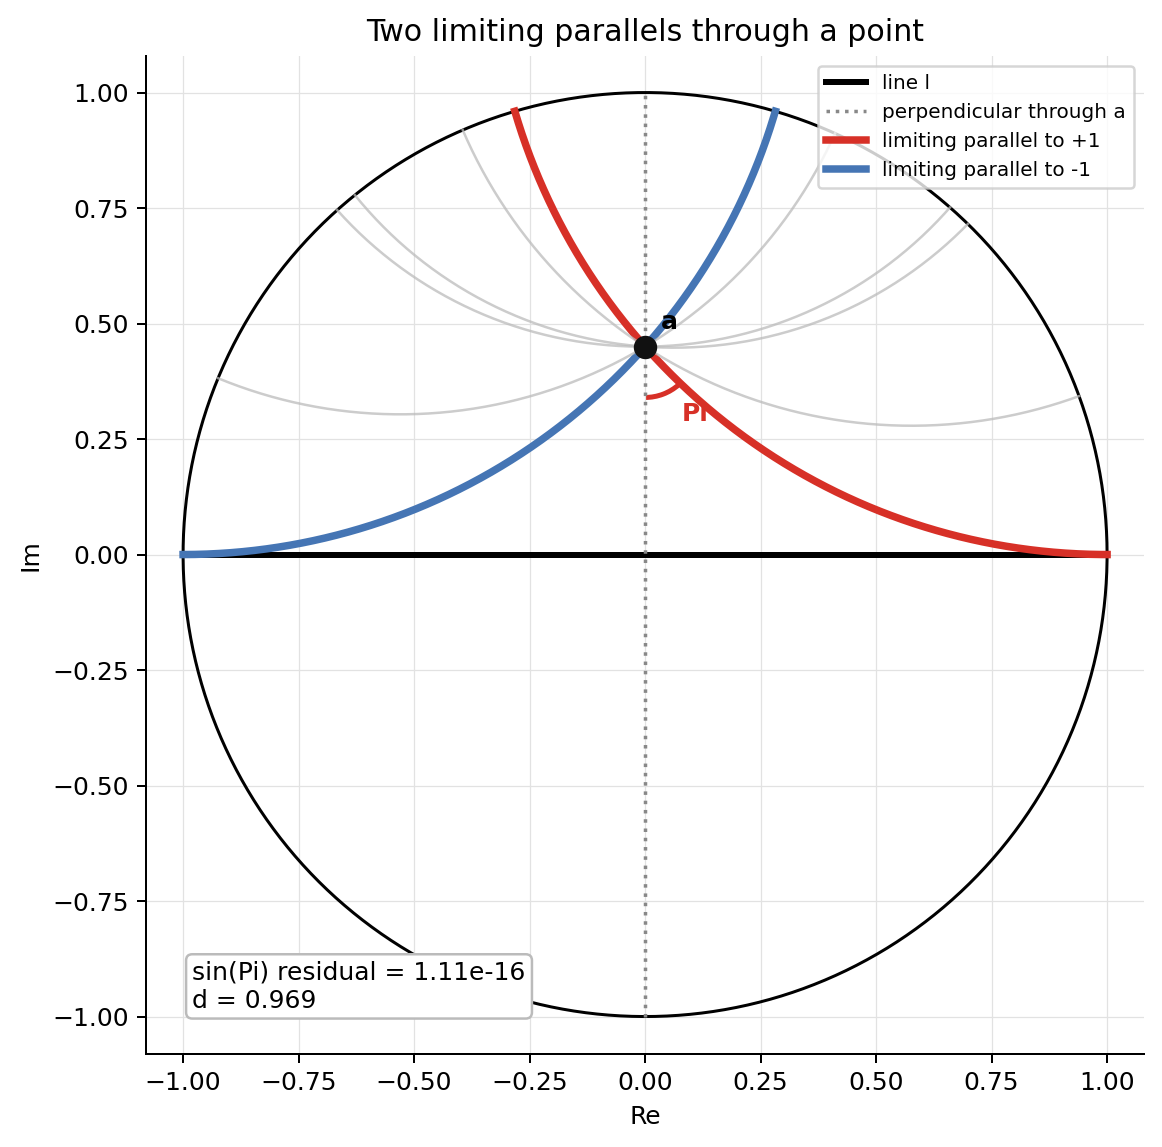

In [7]:
r_point = 0.45
a_disk = 1j * r_point
center_right, radius_right = disk_circle_from_point_and_boundary(a_disk, 1 + 0j)
center_left, radius_left = disk_circle_from_point_and_boundary(a_disk, -1 + 0j)
right_parallel = disk_arc_from_circle(center_right, radius_right, must_contain=a_disk)
left_parallel = disk_arc_from_circle(center_left, radius_left, must_contain=a_disk)

d_to_line = hyp_dist_disk(0j, a_disk)
tangent_right = 1j * (a_disk - center_right)
Pi_measured = angle_between(-1j, tangent_right)
Pi_formula = math.asin(1 / math.cosh(d_to_line))
numeric_checks["parallel_angle_residual"] = abs(Pi_measured - Pi_formula)
numeric_checks["parallel_distance_to_line"] = d_to_line

fig, ax = plt.subplots(figsize=(7.2, 7.2))
format_disk(ax, title="Two limiting parallels through a point")
ax.plot([-1, 1], [0, 0], color="black", lw=2.4, label="line l")
ax.plot([0, 0], [-1, 1], color="#888888", lw=1.4, ls=":", label="perpendicular through a")
plot_complex_curve(ax, right_parallel, color="#d73027", lw=3.0, label="limiting parallel to +1")
plot_complex_curve(ax, left_parallel, color="#4575b4", lw=3.0, label="limiting parallel to -1")
for angle, color in [(0.35, "#bbbbbb"), (0.85, "#bbbbbb"), (2.25, "#bbbbbb"), (2.75, "#bbbbbb")]:
    endpoint = np.exp(1j * angle)
    try:
        pts = disk_geodesic_through_point_to_boundary(a_disk, endpoint, n=260)
        plot_complex_curve(ax, pts, color=color, lw=1.0, alpha=0.75)
    except np.linalg.LinAlgError:
        pass
ax.scatter([0], [r_point], s=70, color="#111111", zorder=5)
ax.text(0.035, r_point + 0.04, "a", weight="bold")
arc = Arc((0, r_point), width=0.22, height=0.22, angle=0, theta1=-90, theta2=-90 + math.degrees(Pi_measured), color="#d73027", lw=2.0)
ax.add_patch(arc)
ax.text(0.08, r_point - 0.16, "Pi", color="#d73027", weight="bold")
ax.text(-0.98, -0.98, f"sin(Pi) residual = {numeric_checks['parallel_angle_residual']:.2e}\nd = {d_to_line:.3f}", bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right", fontsize=8)
path = save_figure(fig, "parallel-angle-and-limiting-geodesics.png")
display_artifact(path, width=700)


## 11.1 And 11.3 Triangle Angle Defect

The Poincare disk is conformal, so hyperbolic angles can be measured as Euclidean angles between the tangent directions of the circular geodesic arcs. Hyperbolic area is different: a geodesic triangle has area equal to its angle defect, $\pi-(\alpha+\beta+\gamma)$.

The code samples each geodesic edge, measures the three tangent angles, and verifies one hyperbolic cosine-rule identity. This is a compact computational scaffold for the chapter's rigidity theme: in hyperbolic geometry, angle data controls size.


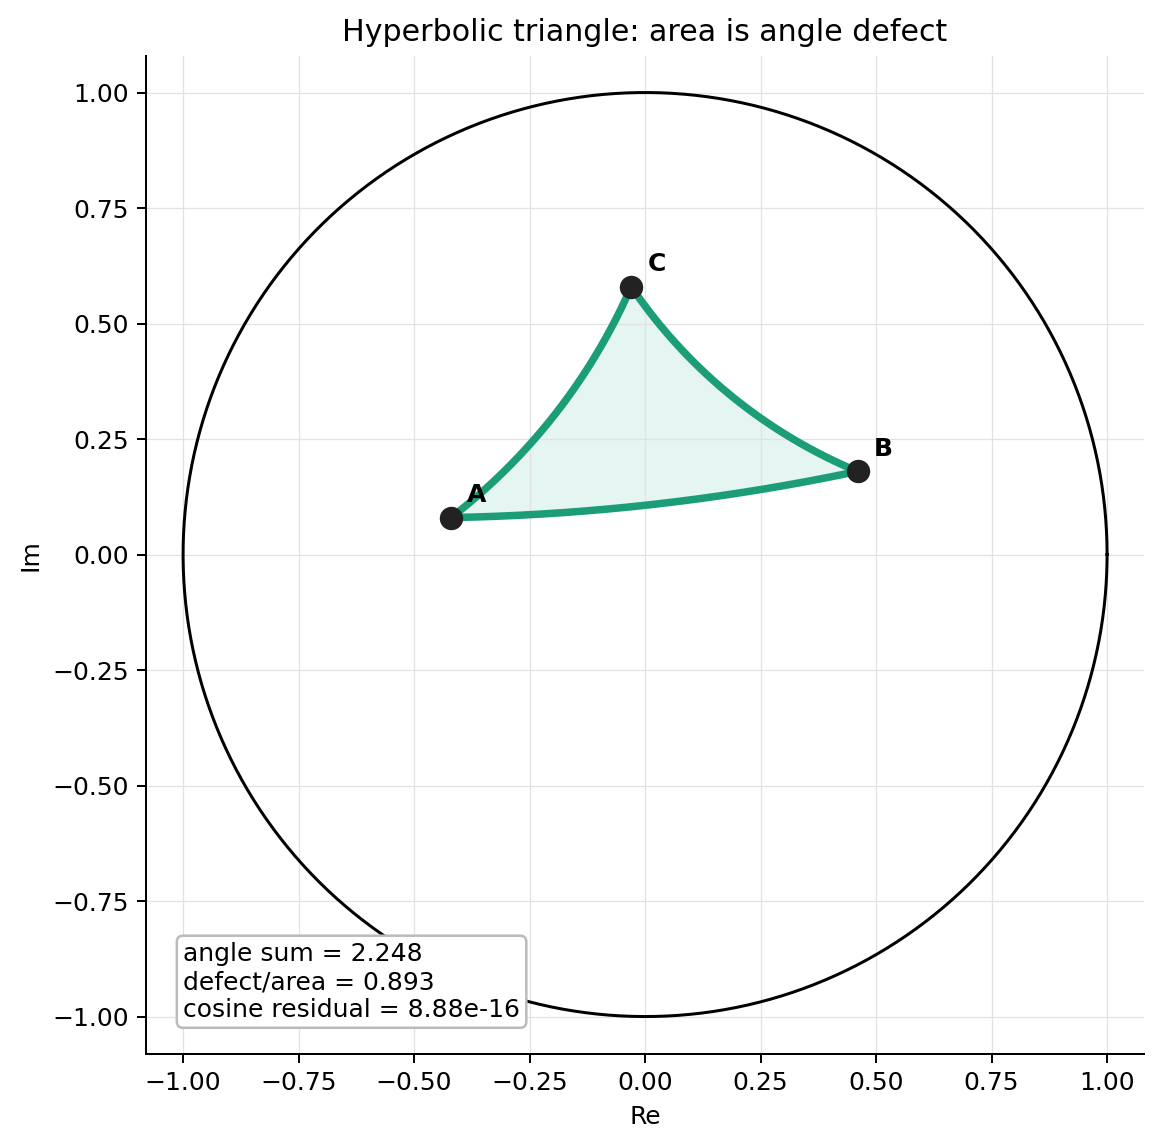

In [8]:
A = -0.42 + 0.08j
B = 0.46 + 0.18j
C = -0.03 + 0.58j
AB = disk_geodesic_segment(A, B, n=260)
BC = disk_geodesic_segment(B, C, n=260)
CA = disk_geodesic_segment(C, A, n=260)
AC = disk_geodesic_segment(A, C, n=260)
BA = disk_geodesic_segment(B, A, n=260)
CB = disk_geodesic_segment(C, B, n=260)

alpha = angle_between(disk_geodesic_tangent(A, B), disk_geodesic_tangent(A, C))
beta = angle_between(disk_geodesic_tangent(B, A), disk_geodesic_tangent(B, C))
gamma = angle_between(disk_geodesic_tangent(C, A), disk_geodesic_tangent(C, B))
angle_sum = alpha + beta + gamma
area_defect = math.pi - angle_sum
side_a = hyp_dist_disk(B, C)
side_b = hyp_dist_disk(A, C)
side_c = hyp_dist_disk(A, B)
cosine_rule_residual = abs(math.cosh(side_a) - (math.cosh(side_b) * math.cosh(side_c) - math.sinh(side_b) * math.sinh(side_c) * math.cos(alpha)))
numeric_checks["triangle_angle_sum"] = angle_sum
numeric_checks["triangle_area_defect"] = area_defect
numeric_checks["triangle_cosine_rule_residual"] = cosine_rule_residual

fig, ax = plt.subplots(figsize=(7.2, 7.2))
format_disk(ax, title="Hyperbolic triangle: area is angle defect")
for pts in (AB, BC, CA):
    plot_complex_curve(ax, pts, color="#1b9e77", lw=3.0)
fill_pts = np.concatenate([AB, BC, CA])
ax.fill(fill_pts.real, fill_pts.imag, color="#80cdc1", alpha=0.20)
for point, label in [(A, "A"), (B, "B"), (C, "C")]:
    ax.scatter(point.real, point.imag, s=70, color="#222222", zorder=5)
    ax.text(point.real + 0.035, point.imag + 0.035, label, weight="bold")
ax.text(-1.0, -1.0, "angle sum = {:.3f}\ndefect/area = {:.3f}\ncosine residual = {:.2e}".format(angle_sum, area_defect, cosine_rule_residual), bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
path = save_figure(fig, "triangle-angle-defect-area.png")
display_artifact(path, width=700)


## 11.5 Beltrami-Klein Model And Cross-Ratio Distance

The Beltrami-Klein map $K(z)=2z/(1+|z|^2)$ sends the Poincare disk to another disk model. It straightens geodesics into Euclidean chords, but it no longer preserves Euclidean angles. That tradeoff is useful: once a geodesic is a chord, the two ideal endpoints $c,d$ of the chord and the two interior points $a,b$ determine the distance by a projective cross-ratio.

The check compares two independent computations of the same distance: Poincare distance before applying $K$, and $\frac12|\log(a,b;c,d)|$ along the Klein chord.


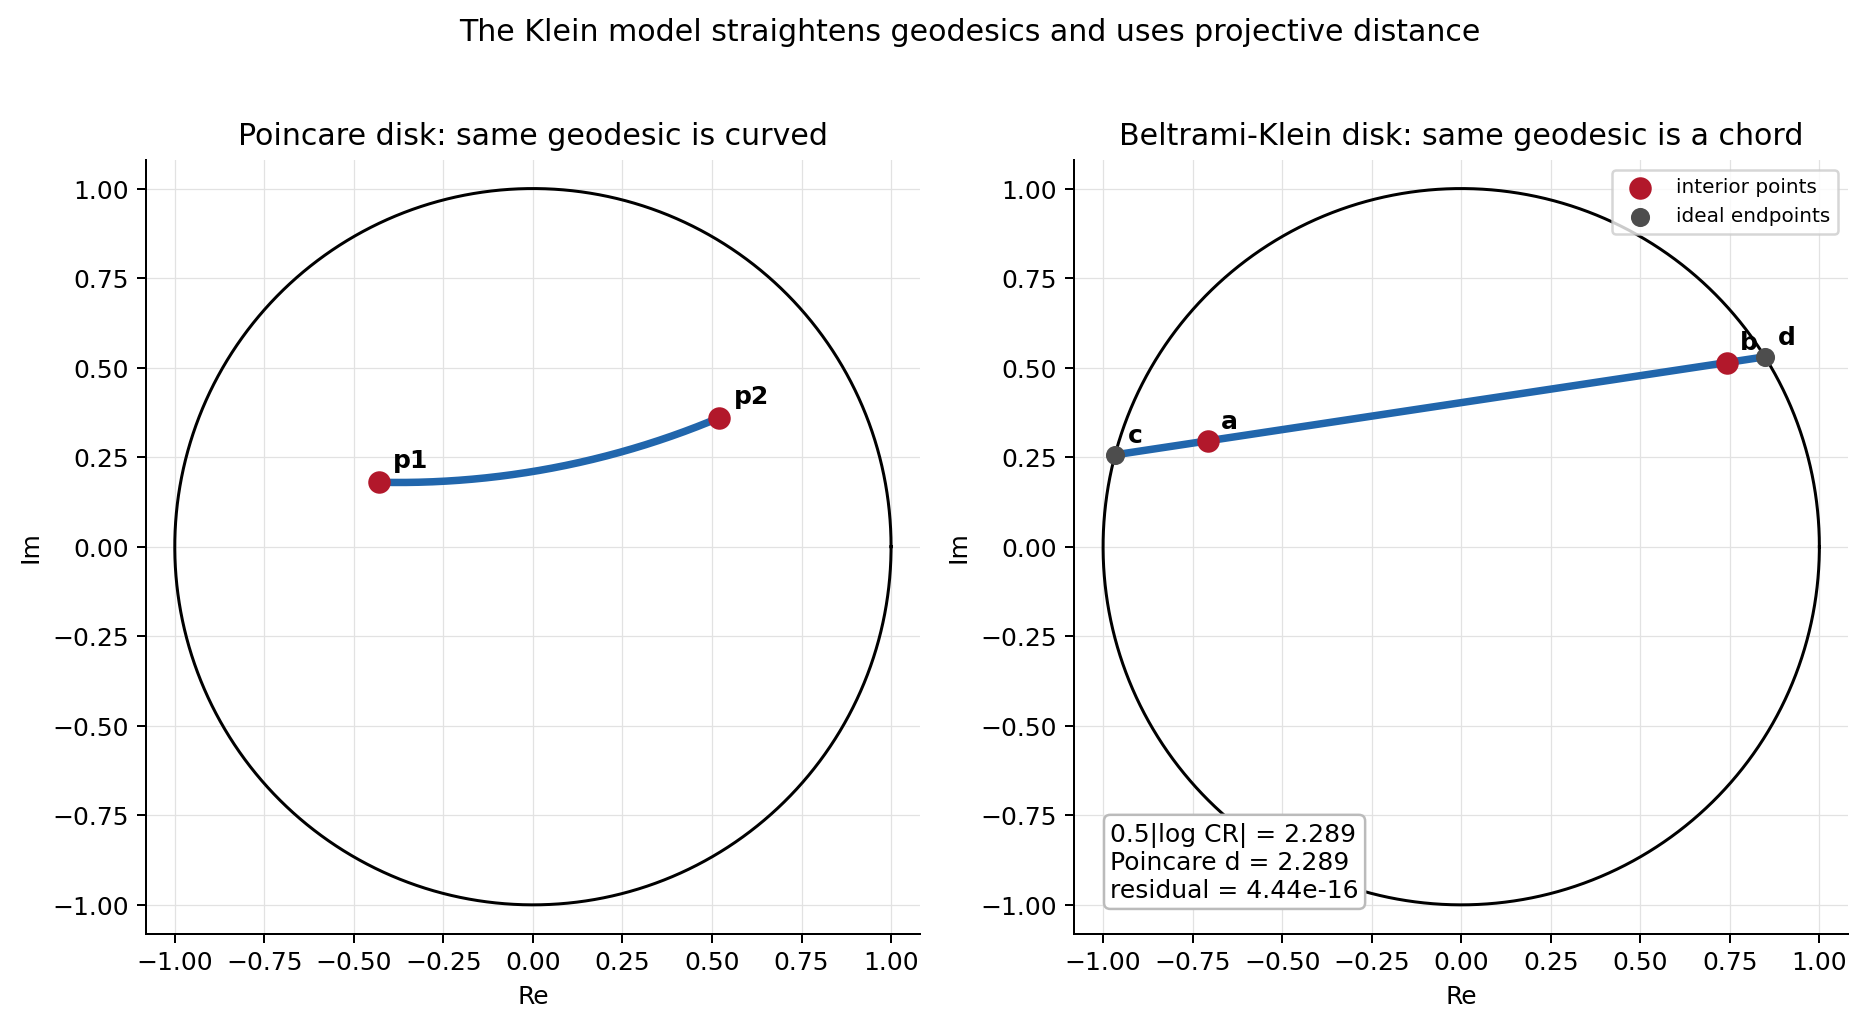

In [9]:
p1 = -0.43 + 0.18j
p2 = 0.52 + 0.36j
k1 = complex(poincare_to_klein(p1))
k2 = complex(poincare_to_klein(p2))
chord_c, chord_d, t_c, t_d, direction = klein_chord_boundary(k1, k2)
t_a = 0.0
t_b = abs(k2 - k1)
cr_value = cross_ratio_real(t_a, t_b, t_c, t_d)
klein_distance = 0.5 * abs(math.log(cr_value))
poincare_distance = hyp_dist_disk(p1, p2)
numeric_checks["klein_cross_ratio_distance_residual"] = abs(klein_distance - poincare_distance)
numeric_checks["klein_cross_ratio_value"] = cr_value

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.6))
ax = axes[0]
format_disk(ax, title="Poincare disk: same geodesic is curved")
geo = disk_geodesic_segment(p1, p2, n=320)
plot_complex_curve(ax, geo, color="#2166ac", lw=3.0)
ax.scatter([p1.real, p2.real], [p1.imag, p2.imag], s=64, color="#b2182b", zorder=5)
ax.text(p1.real + 0.04, p1.imag + 0.04, "p1", weight="bold")
ax.text(p2.real + 0.04, p2.imag + 0.04, "p2", weight="bold")

ax = axes[1]
format_disk(ax, title="Beltrami-Klein disk: same geodesic is a chord")
ax.plot([chord_c.real, chord_d.real], [chord_c.imag, chord_d.imag], color="#2166ac", lw=3.0)
ax.scatter([k1.real, k2.real], [k1.imag, k2.imag], s=64, color="#b2182b", zorder=5, label="interior points")
ax.scatter([chord_c.real, chord_d.real], [chord_c.imag, chord_d.imag], s=44, color="#4d4d4d", zorder=5, label="ideal endpoints")
for point, label in [(k1, "a"), (k2, "b"), (chord_c, "c"), (chord_d, "d")]:
    ax.text(point.real + 0.035, point.imag + 0.035, label, weight="bold")
ax.text(-0.98, -0.98, "0.5|log CR| = {:.3f}\nPoincare d = {:.3f}\nresidual = {:.2e}".format(klein_distance, poincare_distance, numeric_checks["klein_cross_ratio_distance_residual"]), bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#bbbbbb"})
ax.legend(loc="upper right", fontsize=8)
fig.suptitle("The Klein model straightens geodesics and uses projective distance", y=1.02)
path = save_figure(fig, "beltrami-klein-cross-ratio-distance.png")
display_artifact(path, width=980)


## Applied Lab: Distance Invariance Under A Disk Translation

The table below is meant to be edited. Change the base points or the translation parameters and rerun the cell. The invariant to watch is the residual between the original disk distance and the distance after applying the disk automorphism $z\mapsto (z+\tanh(t/2))/(\tanh(t/2)z+1)$.


In [10]:
lab_z = -0.32 + 0.34j
lab_w = 0.38 + 0.18j
base_distance = hyp_dist_disk(lab_z, lab_w)
lab_rows = []
for t in np.linspace(-1.5, 1.5, 9):
    z_t = complex(disk_translate(lab_z, float(t)))
    w_t = complex(disk_translate(lab_w, float(t)))
    moved_distance = hyp_dist_disk(z_t, w_t)
    lab_rows.append({
        "t": float(t),
        "base_distance": base_distance,
        "moved_distance": moved_distance,
        "residual": abs(moved_distance - base_distance),
        "moved_z_real": z_t.real,
        "moved_z_imag": z_t.imag,
        "moved_w_real": w_t.real,
        "moved_w_imag": w_t.imag,
    })
lab_table = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / "mobius-invariance-lab.csv"
lab_table.to_csv(lab_path, index=False)
remember(lab_path)
numeric_checks["lab_max_distance_residual"] = float(lab_table["residual"].max())
lab_table


,t,base_distance,moved_distance,residual,moved_z_real,moved_z_imag,moved_w_real,moved_w_imag
0,-1.500,1.610222,1.610222,6.661338e-16,-0.818169,0.135729,-0.363816,0.182439
1,-1.125,1.610222,1.610222,6.661338e-16,-0.740551,0.181947,-0.184053,0.202303
2,-0.750,1.610222,1.610222,6.661338e-16,-0.634332,0.235685,0.009442,0.209081
3,-0.375,1.610222,1.610222,4.440892e-16,-0.494385,0.291556,0.202206,0.200894
4,0.000,1.610222,1.610222,0.000000e+00,-0.320000,0.340000,0.380000,0.180000
5,0.375,1.610222,1.610222,4.440892e-16,-0.118414,0.369368,0.532861,0.151551
6,0.750,1.610222,1.610222,0.000000e+00,0.094391,0.371049,0.656739,0.121141
7,1.125,1.610222,1.610222,6.661338e-16,0.298199,0.344516,0.752561,0.092933
8,1.500,1.610222,1.610222,0.000000e+00,0.476219,0.297659,0.824138,0.069101


## Final Sanity Checks

The final cell turns the chapter claims into executable checks. It verifies that every concept-named artifact exists, that files are nonblank, and that the numerical or symbolic invariants used above are within tolerance.


In [11]:
tolerances = {
    "cayley_distance_residual": 1e-12,
    "mobius_max_distance_residual": 1e-12,
    "equidistant_ray_max_residual": 1e-12,
    "parallel_angle_residual": 1e-12,
    "triangle_cosine_rule_residual": 1e-12,
    "klein_cross_ratio_distance_residual": 1e-12,
    "lab_max_distance_residual": 1e-12,
}

for key, tol in tolerances.items():
    assert key in numeric_checks, f"missing check: {key}"
    assert float(numeric_checks[key]) <= tol, f"{key}={numeric_checks[key]} exceeds {tol}"
assert numeric_checks["triangle_area_defect"] > 0
assert symbolic_checks.get("cross_ratio_mobius_invariance") is True

artifact_records = []
for path in sorted(set(artifact_paths), key=lambda p: p.as_posix()):
    suffix = path.suffix.lower()
    min_bytes = 128 if suffix in {".json", ".csv"} else 1200
    if suffix == ".html":
        min_bytes = 3000
    checked = assert_artifact(path, min_bytes=min_bytes)
    artifact_records.append({"path": book_rel(checked), "bytes": checked.stat().st_size})

summary = {
    "unit": UNIT,
    "source_span_used": source_span,
    "storyboard_items_implemented": [item["concept"] for item in storyboard["visual sequence"]],
    "libraries_used": {
        "Matplotlib": "durable 2D geodesic, parallel, horocycle, triangle, and Klein diagrams",
        "NumPy": "complex-coordinate model maps and numerical distance checks",
        "Plotly": "interactive Mobius isometry flow saved as HTML",
        "SymPy": "exact cross-ratio invariance under Mobius transformations",
        "pandas": "small editable invariance lab table",
    },
    "artifact_count": len(artifact_records),
    "artifacts": artifact_records,
    "numeric_checks": numeric_checks,
    "symbolic_checks": symbolic_checks,
    "tolerances": tolerances,
    "known_gaps": [
        "The Plotly artifact uses CDN Plotly loading to keep the repository artifact small; the static Mobius PNG remains available offline.",
        "The notebook focuses on Pressley sections 11.1-11.5 and does not attempt a full classification proof of every isometry.",
    ],
}

final_path = write_json(CHECK_DIR / "final-sanity.json", summary)
notebook_sanity = {
    "unit": UNIT,
    "artifact_count": len(artifact_records),
    "artifact_names": [Path(record["path"]).name for record in artifact_records],
    "checks_passed": True,
    "max_recorded_residual": max(float(v) for k, v in numeric_checks.items() if isinstance(v, (int, float, np.floating)) and "residual" in k),
    "source_span": source_span,
}
notebook_sanity_path = write_json(CHECK_DIR / "notebook-sanity.json", notebook_sanity)
assert_artifact(final_path, min_bytes=1000)
assert_artifact(notebook_sanity_path, min_bytes=300)
summary


{'unit': 'chapter-11',
 'source_span_used': {'book': 'Andrew Pressley, Elementary Differential Geometry, Second Edition',
  'chapter': 'Chapter 11: Hyperbolic geometry',
  'printed_pages': '270-304',
  'pdf_pages': '271-306',
  'sections': ['11.1', '11.2', '11.3', '11.4', '11.5'],
  'source_pdf': 'Elementary Differential Geometry (Andrew Pressley).pdf',
  'use': 'orientation only; no copied prose, exercises, screenshots, page crops, or figures'},
 'storyboard_items_implemented': ['upper-half-plane geodesics and disk transfer',
  'Mobius isometry action on geodesics',
  'horocycles and equidistant curves',
  'angle of parallelism',
  'triangle angle defect',
  'Beltrami-Klein cross-ratio distance'],
 'libraries_used': {'Matplotlib': 'durable 2D geodesic, parallel, horocycle, triangle, and Klein diagrams',
  'NumPy': 'complex-coordinate model maps and numerical distance checks',
  'Plotly': 'interactive Mobius isometry flow saved as HTML',
  'SymPy': 'exact cross-ratio invariance under M